# Executive Hotel Booking EDA Report — Day 15

## Executive objective
Conduct a complete end-to-end Exploratory Data Analysis (EDA) of the hotel booking dataset, from data-quality assessment and cleaning through univariate, bivariate, group-wise and correlation analysis.

### Business questions
- What does the booking portfolio look like?
- Where are the main data-quality issues?
- What factors are associated with cancellations?
- How do hotel types, market segments and guest characteristics differ?
- What operational and commercial actions should management consider?


## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
df.head()


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340.00,2.00,2.00,2.00,0.00,0.00,ARE,Direct,Direct,1.00,0.00,6.00,H,H,0.00,Non Refund,103.00,NaN,5.00,Contract,HB,4.00,178.66,0.00,1.00,4.37,No-Show,1.00,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256.00,1.00,2.00,2.00,2.00,0.00,JPN,Groups,Direct,0.00,0.00,0.00,H,H,0.00,No Deposit,80.00,NaN,3.00,Contract,Undefined,3.00,125.81,0.00,0.00,3.63,Canceled,1.00,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41.00,1.00,1.00,4.00,0.00,0.00,POL,Online TA,TA/TO,0.00,0.00,0.00,D,D,0.00,No Deposit,53.00,NaN,2.00,Transient,FB,2.00,148.03,0.00,0.00,3.70,Check-Out,0.00,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23.00,0.00,2.00,2.00,0.00,0.00,CAN,Offline TA/TO,TA/TO,0.00,0.00,0.00,H,H,3.00,No Deposit,96.00,NaN,0.00,Contract,HB,2.00,166.82,0.00,3.00,3.18,Check-Out,0.00,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282.00,0.00,3.00,4.00,0.00,0.00,PRT,Direct,Direct,0.00,0.00,0.00,C,C,0.00,No Deposit,51.00,NaN,3.00,Group,HB,3.00,76.83,0.00,1.00,3.79,Check-Out,0.00,2025-06-01,230.50


## 2. Dataset Structure and Initial Inspection

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Shape: (5771, 35)

Columns:
['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date', 'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Country', 'Market_Segment', 'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned', 'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID', 'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled', 'Reservation_Status_Date', 'Estimated_Revenue']

Data types:


,Data_Type
Booking_ID,object
Hotel_Type,object
Hotel_Location,object
Booking_Date,object
Arrival_Date,object
Lead_Time_Days,float64
Weekend_Nights,float64
Weekday_Nights,float64
Adults,float64
Children,float64



First 5 rows:


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340.00,2.00,2.00,2.00,0.00,0.00,ARE,Direct,Direct,1.00,0.00,6.00,H,H,0.00,Non Refund,103.00,NaN,5.00,Contract,HB,4.00,178.66,0.00,1.00,4.37,No-Show,1.00,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256.00,1.00,2.00,2.00,2.00,0.00,JPN,Groups,Direct,0.00,0.00,0.00,H,H,0.00,No Deposit,80.00,NaN,3.00,Contract,Undefined,3.00,125.81,0.00,0.00,3.63,Canceled,1.00,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41.00,1.00,1.00,4.00,0.00,0.00,POL,Online TA,TA/TO,0.00,0.00,0.00,D,D,0.00,No Deposit,53.00,NaN,2.00,Transient,FB,2.00,148.03,0.00,0.00,3.70,Check-Out,0.00,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23.00,0.00,2.00,2.00,0.00,0.00,CAN,Offline TA/TO,TA/TO,0.00,0.00,0.00,H,H,3.00,No Deposit,96.00,NaN,0.00,Contract,HB,2.00,166.82,0.00,3.00,3.18,Check-Out,0.00,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282.00,0.00,3.00,4.00,0.00,0.00,PRT,Direct,Direct,0.00,0.00,0.00,C,C,0.00,No Deposit,51.00,NaN,3.00,Group,HB,3.00,76.83,0.00,1.00,3.79,Check-Out,0.00,2025-06-01,230.50



Last 5 rows:


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
5766,HTL002956,Resort Hotel,Bali,2025-03-05,2025-08-02,150.00,0.00,7.00,2.00,0.00,0.00,CHN,Groups,Corporate,0.00,0.00,0.00,A,G,1.00,No Deposit,51.00,NaN,0.00,Transient-Party,Undefined,7.00,125.74,2.00,0.00,3.41,Check-Out,0.00,2025-08-07,880.21
5767,HTL012760,City Hotel,Dubai,2025-02-18,2025-11-22,277.00,2.00,3.00,2.00,0.00,0.00,SAU,Corporate,Corporate,0.00,0.00,0.00,D,D,0.00,Non Refund,45.00,"1,017.00",0.00,Transient-Party,BB,5.00,66.99,0.00,0.00,3.29,Canceled,1.00,2025-11-27,334.95
5768,HTL012306,City Hotel,Dubai,2024-06-15,2024-06-30,15.00,1.00,0.00,3.00,0.00,0.00,NaN,Online TA,TA/TO,1.00,0.00,3.00,D,D,0.00,Non Refund,2.00,NaN,0.00,Transient,Undefined,1.00,122.49,0.00,1.00,4.03,Canceled,1.00,2024-06-30,122.49
5769,HTL011138,City Hotel,Amsterdam,2025-06-27,2026-03-19,265.00,0.00,3.00,1.00,0.00,0.00,BEL,Corporate,Corporate,0.00,0.00,0.00,G,G,1.00,Non Refund,57.00,"1,005.00",2.00,Transient,BB,3.00,101.01,1.00,2.00,3.73,Canceled,1.00,2026-03-22,303.04
5770,HTL001688,City Hotel,Lisbon,2024-02-18,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Assessment

In [3]:
# Standardize column names and string values
df.columns = [c.strip() for c in df.columns]

missing_tokens = {"", "NA", "N/A", "NULL", "null", "None", "none", "nan", "NaN", "?", "-", "--"}
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace(list(missing_tokens), np.nan)

# Convert columns that are overwhelmingly numeric
for c in df.columns:
    if df[c].dtype == "object":
        converted = pd.to_numeric(df[c], errors="coerce")
        original_non_null = df[c].notna().sum()
        if original_non_null and converted.notna().sum() / original_non_null >= 0.95:
            df[c] = converted

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique counts:")
display(df.nunique().sort_values().to_frame("Unique_Count"))


Missing values:


,Missing_Count
Company_ID,4718
Country,115
Agent_ID,64
Meal_Type,64
Satisfaction_Score,41
Children,31
Hotel_Location,30
ADR,20
Customer_Type,1
Total_Nights,1


Duplicate rows: 17

Unique counts:


,Unique_Count
Is_Repeated_Guest,2
Is_Canceled,2
Distribution_Channel,3
Babies,3
Reservation_Status,3
Deposit_Type,3
Children,4
Previous_Cancellations,4
Required_Car_Parking_Spaces,4
Customer_Type,4


### Cleaning decisions

- Whitespace and common missing-value tokens are standardized.
- Numeric-looking fields are converted to numeric types where conversion is reliable.
- Missing values are **not blindly filled with zero** because a missing value can have a different business meaning from a true zero.
- For analysis, rows with missing values in the specific variables required for a chart/statistic are excluded only from that calculation.
- Outliers are identified using the IQR rule. They are not automatically deleted because extreme bookings can represent genuine high-value or unusual stays.


## 4. Missing-Value Visualization

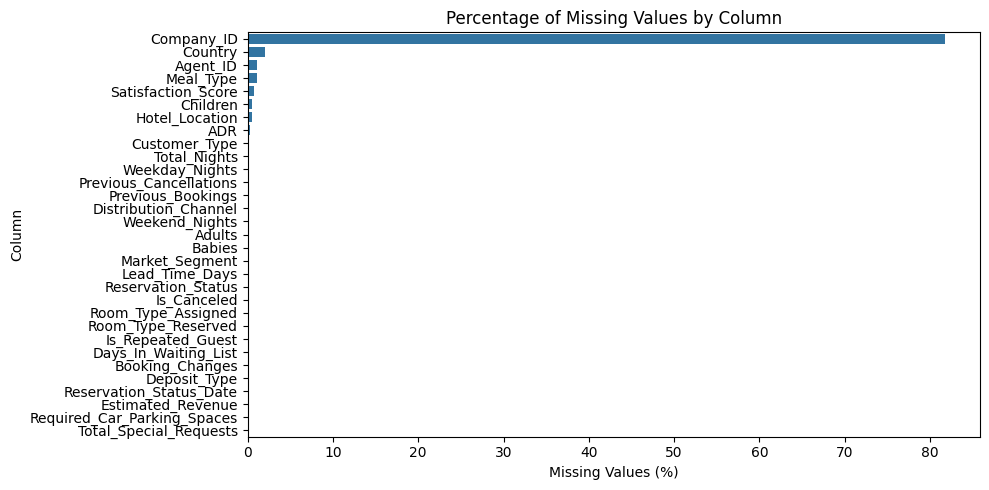

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct):
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_pct.values, y=missing_pct.index)
    plt.title("Percentage of Missing Values by Column")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected after standardization.")


## 5. Outlier Analysis

In [5]:
numeric_cols = df.select_dtypes(include="number").columns

outlier_results = []
for c in numeric_cols:
    s = df[c].dropna()
    if len(s) >= 5 and s.nunique() > 2:
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr > 0:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            n = ((s < lower) | (s > upper)).sum()
            outlier_results.append([c, n, n / len(s) * 100])

outlier_df = pd.DataFrame(
    outlier_results,
    columns=["Column", "Outlier_Count", "Outlier_Percent"]
).sort_values("Outlier_Count", ascending=False)

display(outlier_df)

# Example boxplots for the most relevant continuous variables
continuous_candidates = [c for c in ["lead_time", "adr", "booking_changes", "previous_cancellations"] if c in df.columns]
for c in continuous_candidates:
    plt.figure(figsize=(9, 3))
    sns.boxplot(x=df[c])
    plt.title(f"Box Plot — {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()


,Column,Outlier_Count,Outlier_Percent
7,Days_In_Waiting_List,933,16.17
4,Booking_Changes,301,5.22
12,Estimated_Revenue,132,2.29
11,Satisfaction_Score,71,1.24
9,ADR,67,1.17
3,Children,55,0.96
8,Total_Nights,28,0.49
2,Weekday_Nights,28,0.49
0,Lead_Time_Days,0,0.00
1,Weekend_Nights,0,0.00


## 6. Descriptive Statistics

In [6]:
numeric_cols = df.select_dtypes(include="number").columns
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,"5,770.00",180.70,105.69,0.00,87.00,181.00,273.00,365.00
Weekend_Nights,"5,770.00",1.22,1.06,0.00,0.00,1.00,2.00,3.00
Weekday_Nights,"5,770.00",2.45,2.00,0.00,1.00,2.00,4.00,10.00
Adults,"5,770.00",2.20,0.66,1.00,2.00,2.00,2.00,7.00
Children,"5,740.00",0.38,0.66,0.00,0.00,0.00,1.00,3.00
Babies,"5,770.00",0.04,0.23,0.00,0.00,0.00,0.00,2.00
Is_Repeated_Guest,"5,770.00",0.17,0.37,0.00,0.00,0.00,0.00,1.00
Previous_Cancellations,"5,770.00",0.04,0.24,0.00,0.00,0.00,0.00,3.00
Previous_Bookings,"5,770.00",1.10,2.83,0.00,0.00,0.00,0.00,12.00
Booking_Changes,"5,770.00",0.59,0.90,0.00,0.00,0.00,1.00,4.00


## 7. Univariate Analysis — Booking Status

In [7]:
if "is_canceled" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x="is_canceled")
    plt.title("Booking Cancellation Distribution")
    plt.xlabel("Cancellation Status (0 = Not Cancelled, 1 = Cancelled)")
    plt.ylabel("Number of Bookings")
    plt.tight_layout()
    plt.show()


**Interpretation:** This chart establishes the overall balance between completed/non-cancelled and cancelled bookings. A high cancellation share represents potential revenue uncertainty and should be examined alongside lead time, market segment and deposit policy.

## 8. Univariate Analysis — Lead Time and ADR

In [8]:
for c in [x for x in ["lead_time", "adr"] if x in df.columns]:
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df, x=c, bins=40, kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


**Interpretation:** Histograms reveal the typical booking range, skewness and unusual observations. Lead time and ADR are especially useful for understanding booking behavior and pricing variability.

## 9. Bivariate Analysis — Lead Time vs Cancellation

In [9]:
if "lead_time" in df.columns and "is_canceled" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="is_canceled", y="lead_time")
    plt.title("Lead Time by Cancellation Status")
    plt.xlabel("Cancellation Status")
    plt.ylabel("Lead Time (days)")
    plt.tight_layout()
    plt.show()


**Interpretation:** Comparing the lead-time distributions of cancelled and non-cancelled bookings helps identify whether advance bookings are more exposed to cancellation risk.

## 10. Hotel-Type Performance

In [10]:
if "hotel" in df.columns:
    agg = {"Bookings": ("hotel", "size")}
    if "adr" in df.columns:
        agg["Avg_ADR"] = ("adr", "mean")
    if "is_canceled" in df.columns:
        agg["Cancellation_Rate"] = ("is_canceled", "mean")
    hotel_summary = df.groupby("hotel").agg(**agg)
    if "Cancellation_Rate" in hotel_summary:
        hotel_summary["Cancellation_Rate"] *= 100
    display(hotel_summary)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="hotel", y="adr", estimator="mean", errorbar=None)
    plt.title("Average ADR by Hotel Type")
    plt.xlabel("Hotel Type")
    plt.ylabel("Average Daily Rate")
    plt.tight_layout()
    plt.show()


**Interpretation:** Average ADR compares pricing levels between hotel types. Combining this with cancellation rate helps management evaluate both revenue potential and booking risk.

## 11. Market Segment Analysis

In [11]:
if "market_segment" in df.columns:
    segment = df.groupby("market_segment").agg(
        Bookings=("market_segment", "size"),
        Avg_ADR=("adr", "mean") if "adr" in df.columns else ("market_segment", "size")
    )
    if "is_canceled" in df.columns:
        cancel = df.groupby("market_segment")["is_canceled"].mean() * 100
        segment["Cancellation_Rate"] = cancel
    segment = segment.sort_values("Bookings", ascending=False)
    display(segment)

    plt.figure(figsize=(11, 5))
    sns.barplot(data=df, x="market_segment", y="adr", estimator="mean", errorbar=None)
    plt.title("Average ADR by Market Segment")
    plt.xlabel("Market Segment")
    plt.ylabel("Average Daily Rate")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Interpretation:** Market segments differ in booking volume, price level and cancellation exposure. These differences can guide channel strategy, pricing and deposit requirements.

## 12. Guest Origin Analysis

In [12]:
if "country" in df.columns:
    top_countries = df["country"].value_counts(dropna=True).head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title("Top 10 Guest Countries by Booking Count")
    plt.xlabel("Number of Bookings")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


**Interpretation:** The guest-origin distribution highlights the most important source markets in the booking records and can support localized marketing and demand planning.

## 13. Customer Type and Deposit Policy

In [13]:
if "customer_type" in df.columns and "is_canceled" in df.columns:
    customer_cancel = df.groupby("customer_type")["is_canceled"].mean().mul(100).sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=customer_cancel.values, y=customer_cancel.index)
    plt.title("Cancellation Rate by Customer Type")
    plt.xlabel("Cancellation Rate (%)")
    plt.ylabel("Customer Type")
    plt.tight_layout()
    plt.show()

if "deposit_type" in df.columns and "is_canceled" in df.columns:
    deposit_cancel = df.groupby("deposit_type")["is_canceled"].mean().mul(100).sort_values(ascending=False)
    display(deposit_cancel.to_frame("Cancellation_Rate_Percent"))


**Interpretation:** Customer type and deposit policy can be strong indicators of booking risk. Groups with unusually high cancellation rates may benefit from tighter confirmation, deposit or reminder policies.

## 14. Correlation Analysis

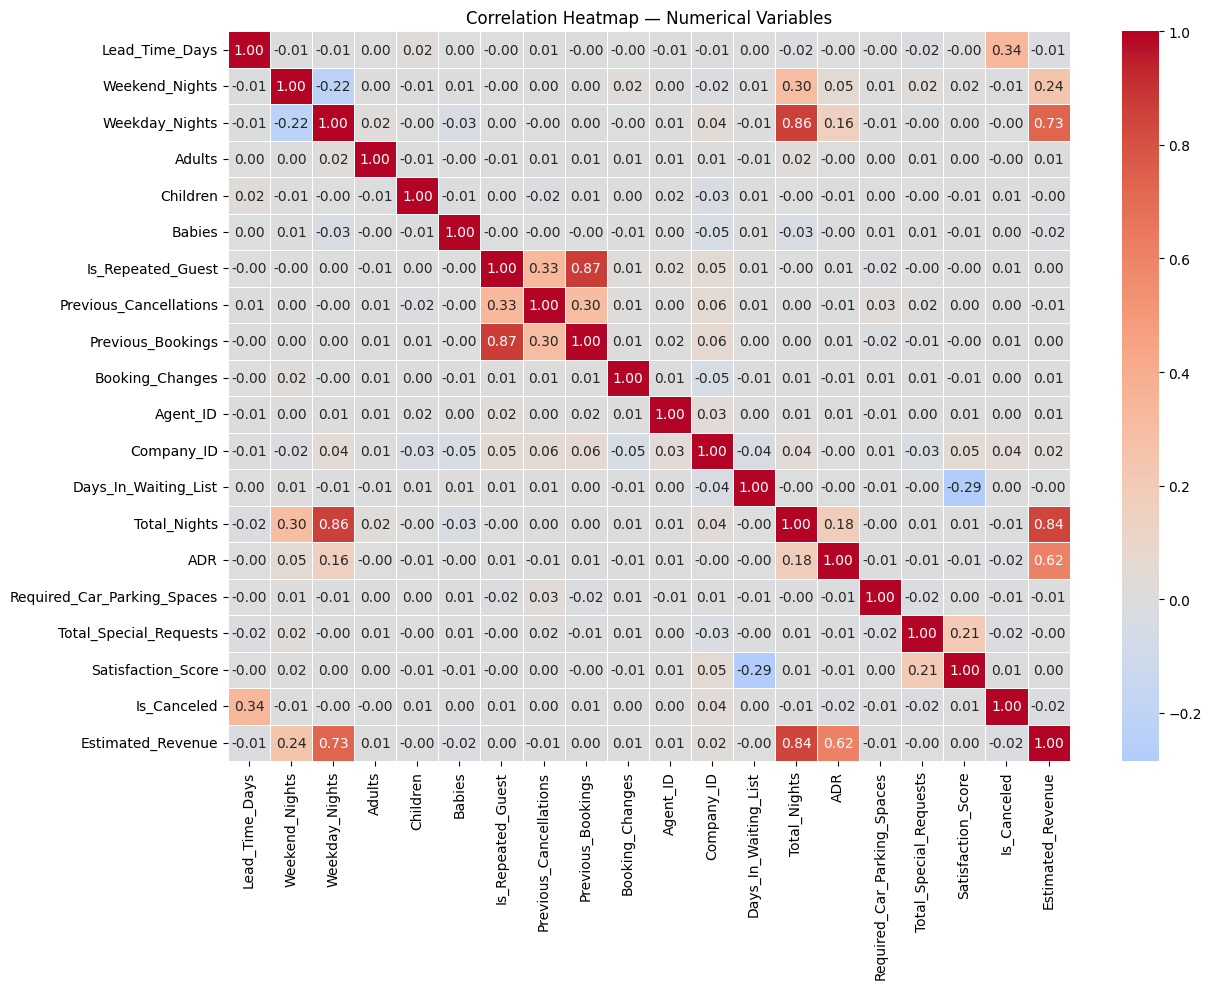

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
Lead_Time_Days,1.00,-0.01,-0.01,0.00,0.02,0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,0.00,-0.02,-0.00,-0.00,-0.02,-0.00,0.34,-0.01
Weekend_Nights,-0.01,1.00,-0.22,0.01,-0.01,0.01,-0.00,0.00,0.00,0.02,0.00,-0.02,0.01,0.30,0.05,0.01,0.02,0.01,-0.01,0.24
Weekday_Nights,-0.01,-0.22,1.00,0.02,-0.00,-0.03,0.00,-0.00,0.00,-0.00,0.01,0.04,-0.01,0.86,0.16,-0.01,-0.00,0.00,-0.00,0.73
Adults,0.00,0.01,0.02,1.00,-0.01,-0.00,-0.01,0.01,0.01,0.01,0.01,0.01,-0.01,0.02,-0.00,0.00,0.01,0.00,-0.00,0.01
Children,0.02,-0.01,-0.00,-0.01,1.00,-0.01,0.00,-0.02,0.01,0.00,0.02,-0.03,0.01,-0.00,-0.01,0.00,-0.00,-0.01,0.01,-0.00
Babies,0.00,0.01,-0.03,-0.00,-0.01,1.00,-0.00,-0.00,-0.00,-0.01,0.01,-0.05,0.01,-0.03,-0.00,0.01,0.01,-0.01,0.00,-0.02
Is_Repeated_Guest,-0.00,-0.00,0.00,-0.01,0.00,-0.00,1.00,0.33,0.87,0.01,0.02,0.05,0.01,-0.00,0.01,-0.02,-0.00,-0.01,0.01,0.00
Previous_Cancellations,0.01,0.00,-0.00,0.01,-0.02,-0.00,0.33,1.00,0.30,0.01,0.00,0.06,0.01,0.00,-0.01,0.03,0.01,0.00,0.00,-0.01
Previous_Bookings,-0.00,0.00,0.00,0.01,0.01,-0.00,0.87,0.30,1.00,0.01,0.01,0.06,0.00,0.00,0.01,-0.02,-0.01,-0.00,0.01,0.00
Booking_Changes,-0.00,0.02,-0.00,0.01,0.00,-0.01,0.01,0.01,0.01,1.00,0.01,-0.05,-0.01,0.01,-0.01,0.01,0.01,-0.01,0.00,0.01


In [14]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap — Numerical Variables")
plt.tight_layout()
plt.show()

display(corr.round(3))


**Interpretation:** The heatmap identifies linear relationships among numerical variables. Strong correlations can indicate useful predictive signals, but correlation does not prove causation.

## 15. Strongest Numerical Relationships

In [15]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(pairs.head(15).to_frame("Correlation"))


,,Correlation
Is_Repeated_Guest,Previous_Bookings,0.87
Weekday_Nights,Total_Nights,0.86
Total_Nights,Estimated_Revenue,0.84
Weekday_Nights,Estimated_Revenue,0.73
ADR,Estimated_Revenue,0.62
Lead_Time_Days,Is_Canceled,0.34
Is_Repeated_Guest,Previous_Cancellations,0.33
Previous_Cancellations,Previous_Bookings,0.30
Weekend_Nights,Total_Nights,0.30
Days_In_Waiting_List,Satisfaction_Score,-0.29


## 16. Executive Key Insights

In [16]:
# Generate concise, data-driven insights from the current dataset.
insights = []

if "is_canceled" in df.columns:
    rate = df["is_canceled"].mean() * 100
    insights.append(f"Overall cancellation rate: {rate:.1f}%.")

if "lead_time" in df.columns and "is_canceled" in df.columns:
    c = df[["lead_time", "is_canceled"]].corr().iloc[0, 1]
    insights.append(f"Lead time vs cancellation correlation: {c:.2f}.")

if "adr" in df.columns and "is_canceled" in df.columns:
    c = df[["adr", "is_canceled"]].corr().iloc[0, 1]
    insights.append(f"ADR vs cancellation correlation: {c:.2f}.")

if "hotel" in df.columns:
    hs = df.groupby("hotel").agg(
        Avg_ADR=("adr", "mean") if "adr" in df.columns else ("hotel", "size"),
        Cancellation_Rate=("is_canceled", "mean") if "is_canceled" in df.columns else ("hotel", "size")
    )
    if "Cancellation_Rate" in hs:
        hs["Cancellation_Rate"] *= 100
    display(hs)
    if "Avg_ADR" in hs:
        insights.append(f"Highest average ADR hotel type: {hs['Avg_ADR'].idxmax()}.")
    if "Cancellation_Rate" in hs:
        insights.append(f"Highest cancellation-rate hotel type: {hs['Cancellation_Rate'].idxmax()}.")

for i, x in enumerate(insights, 1):
    print(f"{i}. {x}")


## 17. Management Recommendations

1. **Strengthen cancellation-risk controls:** Use lead time, customer type and market segment as risk indicators and apply targeted confirmation/reminder policies.

2. **Optimize pricing by hotel type and segment:** Monitor ADR distributions and segment-level booking behavior rather than using a single pricing strategy across all customers.

3. **Protect high-risk bookings:** Consider deposits or stricter cancellation conditions for segments with persistently high cancellation rates, while avoiding unnecessary friction for reliable segments.

4. **Prioritize major source markets:** Concentrate marketing and partnership activity on the largest guest-origin markets while testing localized campaigns for growth markets.

5. **Use booking-channel intelligence:** Compare market segments and distribution channels on both volume and cancellation exposure before increasing acquisition spend.

6. **Monitor outliers rather than automatically removing them:** Very high ADR, lead-time or stay values may represent genuine business cases. Investigate extreme records before deciding whether to cap or exclude them.

7. **Build an ongoing KPI dashboard:** Track booking volume, cancellation rate, ADR, lead time, segment mix and source-market mix monthly so management can detect changes early.


## 18. Executive Conclusion

The hotel booking EDA provides a structured view of data quality, booking behavior, pricing, customer mix and cancellation risk. The most valuable management signals come from combining **cancellation status with lead time, ADR, hotel type, customer type and market segment**.

The analysis should be used as a decision-support baseline: relationships identified through EDA can guide further forecasting or predictive modelling, while operational decisions should also consider capacity, seasonality, policy constraints and business context.
